Train X & Y shapes: (1600, 2352) (1600,)
Test X & Y shapes: (400, 2352) (400,)


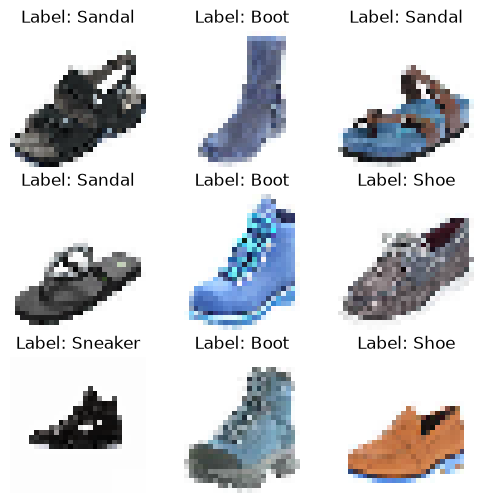

Epoch 1/100


c:\Users\raoaf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3994 - loss: 1.5657
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5587 - loss: 1.0193
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6044 - loss: 0.8946
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6419 - loss: 0.7852
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6562 - loss: 0.7221
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6625 - loss: 0.6546
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7506 - loss: 0.5611
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8712 - loss: 0.4562
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8894 - loss: 0.3839
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8894 - loss: 0.3379
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8838 - loss: 0.3204
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8963 - lo

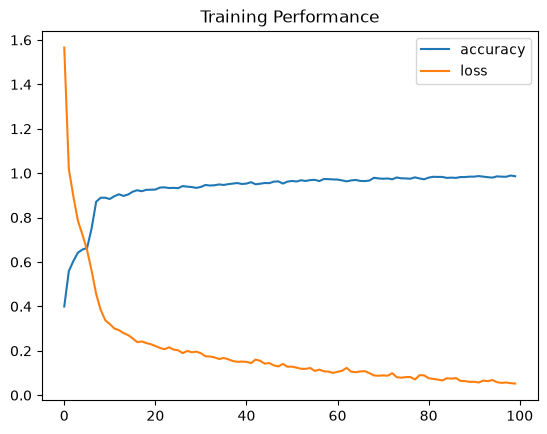

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Activation

# 2. Load custom CSV data
csv_path = 'C:\\My Files\\ANN & ML Projects\\ANNDL_Fall_2026\\Project_ANNDL_Fall_2026\\data\\processed\\Images28.csv'
data = pd.read_csv(csv_path, header=None)

# Separate labels (first column) and features (pixel values)
Y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values

# Normalize pixel values (0-255 to 0-1) for neural network stability
X = X / 255.0

# 3. Train / Test Split (80% train, 20% test)
trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=42)

print('Train X & Y shapes:', trainX.shape, trainY.shape)
print('Test X & Y shapes:', testX.shape, testY.shape)

# 4. Plot 9 sample images from your dataset
label_names = {0: 'Boot', 1: 'Sandal', 2: 'Shoe', 3: 'Sneaker'}

plt.figure(figsize=(6, 6))
for i in range(min(9, len(trainX))):
    plt.subplot(3, 3, i + 1)

    img = trainX[i].reshape(28, 28, 3)
    plt.imshow(img)
    plt.title('Label: %s' % label_names.get(trainY[i], trainY[i]))
    plt.axis('off')
plt.show()

# 5. One-hot encode targets for 4 classes
num_classes = 4
trainY = to_categorical(trainY, num_classes)
testY = to_categorical(testY, num_classes)

# 6. Build Sequential Model
# UPDATED: input_dim changed from 784 to 2352
model = Sequential([
    Dense(45, input_dim=2352),
    Activation('relu'),
    Dense(num_classes),
    Activation('softmax')
])

# 7. Compile Model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 8. Train Model
m = model.fit(trainX, trainY, epochs=100, batch_size=64, verbose=1)

# 9. Evaluate Model
performance = model.evaluate(testX, testY, verbose=0)
print('Test Loss:', performance[0])
print('Test Accuracy:', performance[1])

performance = model.evaluate(trainX, trainY, verbose=0)
print('Train Loss:', performance[0])
print('Train Accuracy:', performance[1])

# 10. Plot Training Loss and Accuracy History
pd.DataFrame(m.history).plot()
plt.title('Training Performance')
plt.show()

# 11. Save Trained Model to Google Drive
model.save('C:\\My Files\\ANN & ML Projects\\ANNDL_Fall_2026\\Project_ANNDL_Fall_2026\\models\\images28_model.keras')

In [ ]:

import cv2
import numpy as np
import tensorflow as tf

model1 = tf.keras.models.load_model(r"C:\My Files\ANN & ML Projects\ANNDL_Fall_2026\Project_ANNDL_Fall_2026\models\images28_model.keras")
image = cv2.imread(r"C:\My Files\ANN & ML Projects\ANNDL_Fall_2026\Project_ANNDL_Fall_2026\data\sample\sneaker.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image1 = cv2.resize(image, (28, 28))
image1 = image1 / 255.0
test_img = image1.reshape(1, 2352)
p = model1.predict(test_img)
labels = {0: "Boot", 1: "Sandal", 2: "Shoe", 3: "Sneaker"}
ind = np.argmax(p)
print(labels[ind])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Sandal
